In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.metrics import r2_score

In [3]:
from sklearn.pipeline import Pipeline

In [18]:
x=6*np.random.rand(200,1) - 3

y= 2*x**3+10*x**2 + 0.9*x + 2 *np.random.rand(200,1)

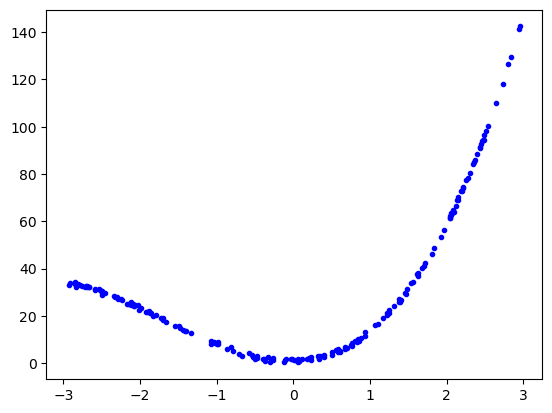

In [19]:
plt.plot(x,y,"b.")

In [20]:
from sklearn.model_selection import train_test_split

In [21]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [25]:
from sklearn.linear_model import LinearRegression

In [26]:
lr=LinearRegression()

In [27]:
lr.fit(x_train,y_train)

LinearRegression()

In [28]:
y_pred=lr.predict(x_test)

In [29]:
r2_score(y_test,y_pred)

0.1818213180389916

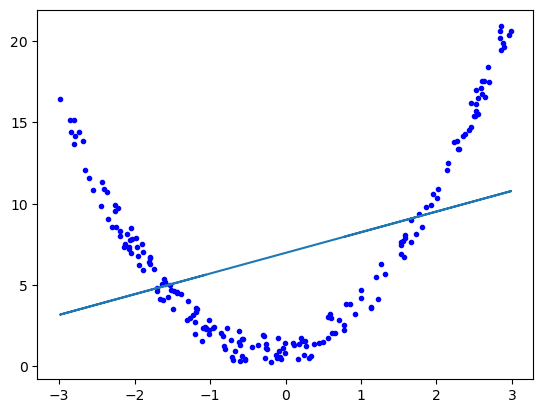

In [34]:
plt.plot(x,y,"b.")
plt.plot(x,lr.predict(x))

In [7]:
poly=PolynomialFeatures(degree=2,include_bias=True)

In [12]:
x_train_sc=poly.fit_transform(x_train)

In [13]:
x_test_sc=poly.transform(x_test)

In [57]:
x_new=poly.transform(x)

In [58]:
x_train_sc.shape

(160, 3)

In [59]:
LR=LinearRegression()

In [60]:
LR.fit(x_train_sc,y_train)

LinearRegression()

In [61]:
y_predi=LR.predict(x_test_sc)

In [62]:
r2_score(y_test,y_predi)

0.9875084448656237

In [63]:
y_new=LR.predict(x_new)

In [66]:
X_new=np.linspace(-3, 3, 200).reshape(200, 1)
X_new_poly = poly.transform(X_new)
y_new = LR.predict(X_new_poly)

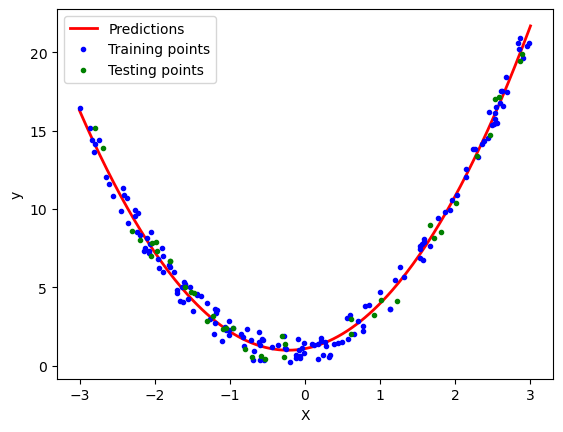

In [67]:
plt.plot(X_new, y_new, "r-", linewidth=2, label="Predictions")
plt.plot(x_train, y_train, "b.",label='Training points')
plt.plot(x_test, y_test, "g.",label='Testing points')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

In [22]:
def polynomial_regression(degree):
    polynom=PolynomialFeatures(degree=degree,include_bias=False)
    sc=StandardScaler()
    LR=LinearRegression()
    
#     x_new=np.linspace(-3,3,100).reshape(100,1)
    
#     x_new=polynom.fit_transform(x_new)
    
    pipe=Pipeline([
        ("poly",polynom),
        ("sc",sc),
        ("LR",LR)
    ])
    pipe.fit(x,y)
    x_curve = np.linspace(x.min(), x.max(), 100).reshape(-1, 1)
    y_curve = pipe.predict(x_curve)
    
#     y_new=pipe.predict(x_new)
 
    plt.plot(x_curve,y_curve,"r",label="Degree"+str(degree),linewidth=2)
    plt.plot(x_train,y_train,"b.",linewidth=2)
    plt.plot(x_test,y_test,"g.",linewidth=2)
    plt.legend(loc="upper left")

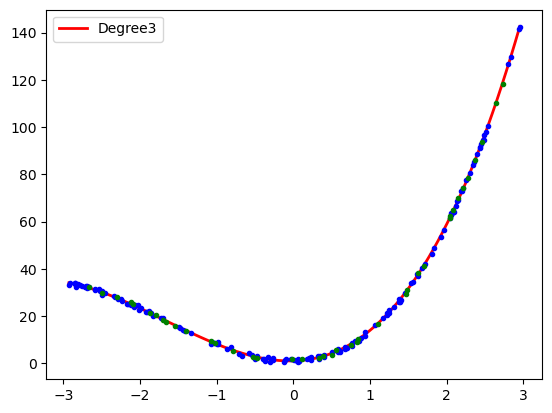

In [27]:
polynomial_regression(3)